Name: Mia Parker

Github Username: emeliap-usc

ID: 1412-4907-44

# 1.

## a)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


df = pd.read_excel("../data/Folds5x2_pp.xlsx")

In [65]:
df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


## b)

In [66]:
df.shape

(9568, 5)

Rows: 9568
Columns: 5

Features consist of hourly average ambient variables of Ambient Pressure (AP), Relative Humidity (RH), Exhaust Vacuum (V), Temperature (AT), and Net hourly electrical energy output (PE).

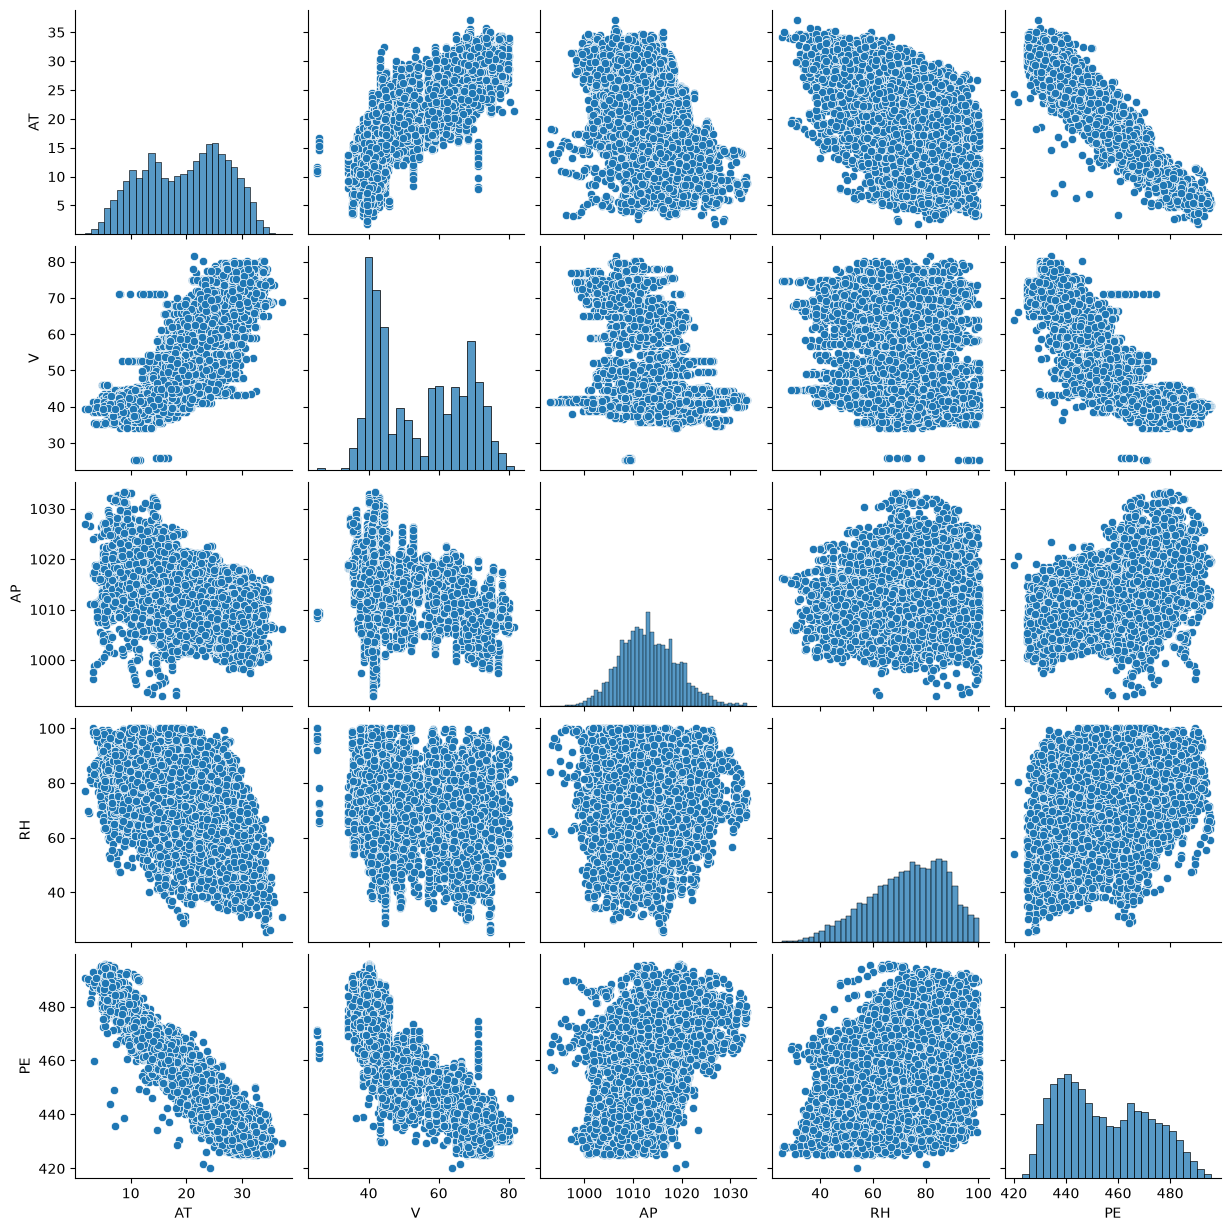

In [67]:
sns.pairplot(df)

For variables AT and V, they both have a visible negative correlation with PE. Looking at PE's relationship with AP and RH, it is possible there is a correlation, but it is not nearly so obvious as the other two independent variables.

In [68]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


AT IQR: 25.72 - 13.51 = 12.209

V IQR: 66.54 - 41.74 = 24.8

AP IQR:1017.26 - 1009.10 = 8.159

RH IQR: 84.83 - 63.3275 = 21.502

PE IQR: 468.43 - 439.75 = 28.68

## c)

### AT

In [69]:
X = df["AT"]
y = df["PE"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:00:58   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

Because P>|t| = 0.000, AT is statistically significant as a predictor of PE.

PE_hat = 497.46 - 2.1713(AT)

<Axes: xlabel='AT', ylabel='PE'>

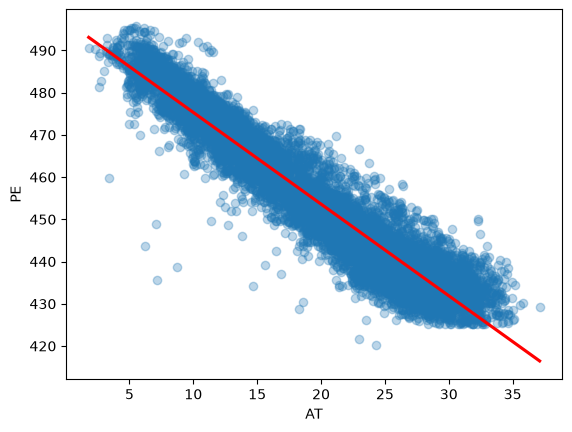

In [70]:
sns.regplot(x="AT", y="PE", data=df, scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})

### V

In [71]:
X = df["V"]
y = df["PE"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:00:58   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.0

Because P>|t| = 0.000, V is statistically significant as a predictor of PE.

PE_hat = 517.80 - 1.1681(V)

<Axes: xlabel='V', ylabel='PE'>

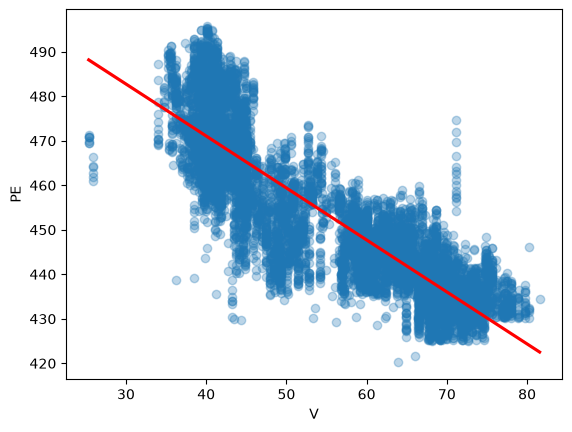

In [72]:
sns.regplot(x="V", y="PE", data=df, scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})

### AP

In [73]:
X = df["AP"]
y = df["PE"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:00:59   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.0

Because P>|t| = 0.000, AP is statistically significant as a predictor of PE.

PE_hat = -1055.26 + 1.4899(AP)

<Axes: xlabel='AP', ylabel='PE'>

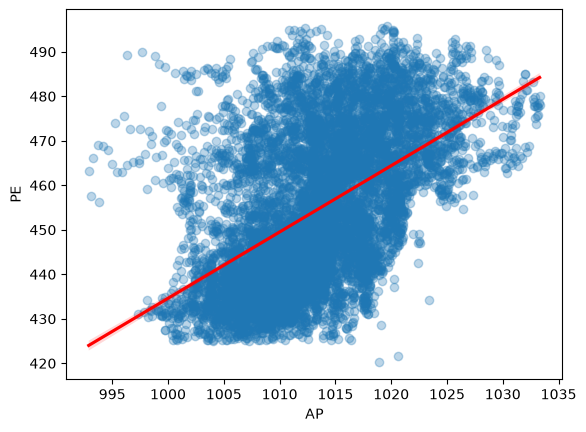

In [74]:
sns.regplot(x="AP", y="PE", data=df, scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})

### RH

In [75]:
X = df["RH"]
y = df["PE"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:00:59   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.0

Because P>|t| = 0.000, RH is statistically significant as a predictor of PE.

PE_hat = 420.96 + 0.4557(RH)

<Axes: xlabel='RH', ylabel='PE'>

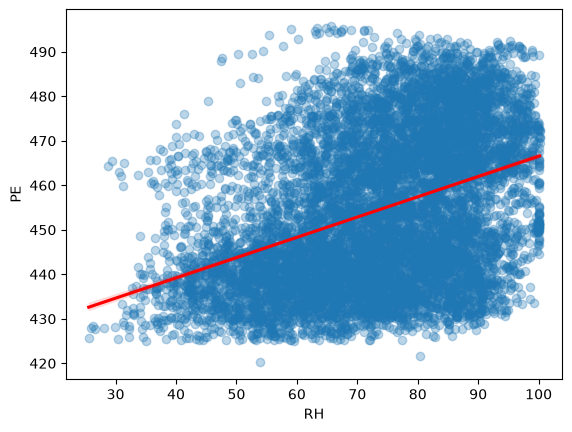

In [76]:
sns.regplot(x="RH", y="PE", data=df, scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})

While each graph has some points that I would consider outliers, there are multiple points. This would point to more of a subset pattern then actual outliers. If there was a single outlier point that I believed didn't belong and was skewing our models, then I would remove it.

## d)

In [77]:
X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:01:00   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

At the 5% significance level, we reject \(H_0: \beta_j=0\) for AT, V, AP, and RH because their p-values are less than 0.05. 

## e)

Surprisingly, our results have not significantly changed from those in part c. All independent variables remain significant.

In [78]:
simple_coefs = {"AT":-2.1713, "V":-1.1681, "AP":1.4899, "RH":0.4557}
multiple_coefs = {"AT":-1.9775, "V":-0.2339, "AP":0.0621, "RH":-0.1581}
comparison = pd.DataFrame({
    "simple": simple_coefs,
    "multiple": multiple_coefs
})

Text(0.5, 1.0, 'Simple vs. Multiple Regression Coefficients')

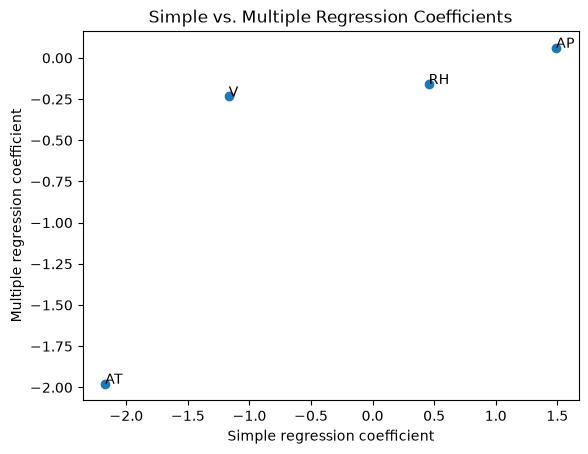

In [79]:
for predictor in comparison.index:
    plt.annotate(
        predictor,
        (comparison.loc[predictor, "simple"],
         comparison.loc[predictor, "multiple"])
    )

plt.scatter(comparison["simple"], comparison["multiple"])

plt.xlabel("Simple regression coefficient")
plt.ylabel("Multiple regression coefficient")
plt.title("Simple vs. Multiple Regression Coefficients")

We can see that the coefficients changed slightly between simple regression and multiple regression, but this is not surprising, as other relationships are being taken into account. This does nto mean that the relationship between independent and dependent variable have changed.

## f)

### AT

In [80]:
X = df["AT"]
y = df["PE"]
X_poly = pd.DataFrame({
    "T": X,
    "T_squared": X**2,
    "T_cubed": X**3
})
X_poly = sm.add_constant(X_poly)
model = sm.OLS(y, X_poly).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:01:00   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.0

### V

In [81]:
X = df["V"]
y = df["PE"]
X_poly = pd.DataFrame({
    "T": X,
    "T_squared": X**2,
    "T_cubed": X**3
})
X_poly = sm.add_constant(X_poly)
model = sm.OLS(y, X_poly).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:01:00   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        554.1468      9.151     60.557      0.0

### AP

In [82]:
X = df["AP"]
y = df["PE"]
X_poly = pd.DataFrame({
    "T": X,
    "T_squared": X**2,
    "T_cubed": X**3
})
X_poly = sm.add_constant(X_poly)
model = sm.OLS(y, X_poly).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1813.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:01:00   Log-Likelihood:                -39184.
No. Observations:                9568   AIC:                         7.837e+04
Df Residuals:                    9565   BIC:                         7.840e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0747      0.009      8.415      0.0

/var/folders/xs/b3tzbf4n5z7fv8f5jndqz0k40000gn/T/ipykernel_29382/1659582819.py:9: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y, X_poly).fit()


### RH

In [83]:
X = df["RH"]
y = df["PE"]
X_poly = pd.DataFrame({
    "T": X,
    "T_squared": X**2,
    "T_cubed": X**3
})
X_poly = sm.add_constant(X_poly)
model = sm.OLS(y, X_poly).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:01:00   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        468.4135     10.545     44.422      0.0

Looking at t values, as the P>|t| values are too small, running a model with our variable^2 and ^3 only made a noticable difference to variables AT and V. For AT, |t| became more extreme, going from ~4 at AT to ~22 for AT^3. The oposite effect took place for V. |t| went from ~4 for V, to ~2 for V^3. So this method did not improve the model like it did for variable AT.

## g)

In [84]:

model_interactions = smf.ols(
    "PE ~ AT:AP + AT:RH + AT:V + AP:RH + AP:V + RH:V + AT + V + AP + RH",
    data=df
).fit()

print(model_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:01:00   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

All pairwise interactions have P>|t| less than 0.05, so they are all statistically significant.

## h)

In [85]:
training, testing = train_test_split(df, test_size=0.30, random_state=42)

testing

,AT,V,AP,RH,PE
2513,19.64,48.06,1014.81,74.96,455.27
9411,28.26,69.23,1013.01,42.10,436.31
8745,27.98,67.17,1007.32,75.29,440.68
9085,28.64,69.23,1013.11,37.13,434.40
4950,9.34,38.08,1019.56,67.74,482.06
...,...,...,...,...,...
981,17.90,48.98,1014.17,80.40,453.02
4694,29.70,57.35,1005.63,57.35,433.27
1407,12.52,41.44,1016.08,68.94,477.18
535,9.75,40.81,1026.00,84.44,481.95


In [86]:
X_train = training[["AT", "V", "AP", "RH"]]
y_train = training["PE"]
X_train = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train).fit()

In [87]:
train_predictions = model.predict(X_train)

X_test = testing[["AT", "V", "AP", "RH"]]
y_test = testing["PE"]
X_test = sm.add_constant(X_test)

test_predictions = model.predict(X_test)


train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Training MSE: 20.580839725738695
Testing MSE: 21.239856938225454


### Improved Model

In [88]:
X_train = training[["AT", "V", "AP", "RH"]]
y_train = training["PE"]

def create_features(data):
    lst = ["AT", "V", "AP", "RH"]
    for i in lst:
        data[f"{i}2"] = data[i]**2

    for i in range(0, len(lst)):
        lst2 = lst[i+1:]
        for j in lst2:
            data[f"{lst[i]}_{j}"] = data[lst[i]] * data[j]

create_features(X_train)

In [93]:
X_train = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train).fit()

results = pd.DataFrame({
    "Coefficient": model.params,
    "P-value": model.pvalues.round(3)
})

print(results)


        Coefficient  P-value
const -10457.507603      0.0
AT        -2.429290      0.0
V         -0.454214      0.0
AP        21.153085      0.0
RH         5.675420      0.0
AT2        0.016994      0.0
AP2       -0.010195      0.0
RH2       -0.002078      0.0
AT_V       0.008017      0.0
AT_RH     -0.006881      0.0
AP_RH     -0.005293      0.0


Drop those that are insignificant and not involved in other interactions: V2, AT_AP, V_AP, and V_RH

In [94]:
X_train = training[["AT", "V", "AP", "RH"]]
y_train = training["PE"]

create_features(X_train)

X_train = X_train.drop(["V2", "AT_AP", "V_RH", "V_AP"], axis=1)
X_train = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train).fit()

results = pd.DataFrame({
    "Coefficient": model.params,
    "P-value": model.pvalues.round(3)
})

print(results)

        Coefficient  P-value
const -10457.507603      0.0
AT        -2.429290      0.0
V         -0.454214      0.0
AP        21.153085      0.0
RH         5.675420      0.0
AT2        0.016994      0.0
AP2       -0.010195      0.0
RH2       -0.002078      0.0
AT_V       0.008017      0.0
AT_RH     -0.006881      0.0
AP_RH     -0.005293      0.0


In [97]:

train_predictions = model.predict(X_train)

X_test = testing[["AT", "V", "AP", "RH"]]
y_test = testing["PE"]

create_features(X_test)

X_test = X_test.drop(["V2", "AT_AP", "V_RH", "V_AP"], axis=1)
X_test = sm.add_constant(X_test)

test_predictions = model.predict(X_test)


train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Training MSE: 17.917812671185736
Testing MSE: 18.694346190795404


## i)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

X_train = training[["AT", "V", "AP", "RH"]]
y_train = training["PE"]

X_test = testing[["AT", "V", "AP", "RH"]]
y_test = testing["PE"]

### Raw Features

In [ ]:
train_errors = []
test_errors = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

k_nearest = pd.DataFrame({"k": range(1, 101), "train_error": train_errors, "test_error": test_errors})
k_nearest.sort_values(by='test_error', ascending=True).iloc[0]


k               7.000000
train_error    13.460206
test_error     19.770879
Name: 6, dtype: float64

Text(0, 0.5, 'Test Error')

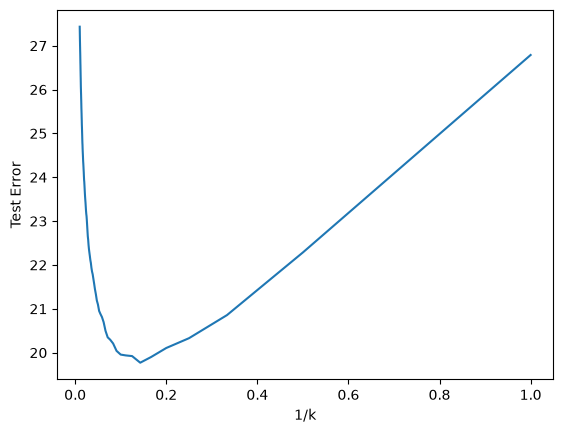

In [ ]:
plt.plot([1/k for k in range(1, 101)], test_errors)

plt.xlabel("1/k")
plt.ylabel("Test Error")

Text(0, 0.5, 'Train Error')

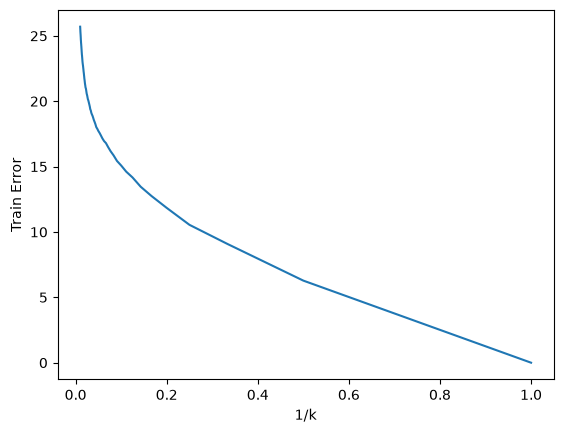

In [ ]:
plt.plot([1/k for k in range(1, 101)], train_errors)

plt.xlabel("1/k")
plt.ylabel("Train Error")

### Normalized Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 1.68387924e+00,  1.24377012e+00,  2.44766635e-03,
        -1.18993267e+00],
       [ 8.09376113e-01,  1.27065606e+00, -7.01199764e-01,
         1.19493429e+00],
       [ 6.35831306e-01,  6.33301115e-01, -2.77677377e-01,
        -2.08576788e-01],
       ...,
       [ 1.57405792e+00,  1.58775201e+00, -6.09139506e-02,
        -2.52388800e+00],
       [ 6.46677856e-01,  1.20185968e+00,  9.58226809e-02,
        -7.39541972e-01],
       [ 2.56202041e-01,  6.53860952e-01,  6.57740179e-01,
        -3.62150375e-01]], shape=(6698, 4))

In [ ]:
train_errors_scaled = []
test_errors_scaled = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    
    train_errors_scaled.append(mean_squared_error(y_train, train_pred))
    test_errors_scaled.append(mean_squared_error(y_test, test_pred))

In [ ]:
k_nearest = pd.DataFrame({"k": range(1, 101), "train_error": train_errors_scaled, "test_error": test_errors_scaled})
k_nearest.sort_values(by='test_error', ascending=True).iloc[0]

k               7.000000
train_error    12.198978
test_error     18.156725
Name: 6, dtype: float64

Text(0, 0.5, 'Test Error')

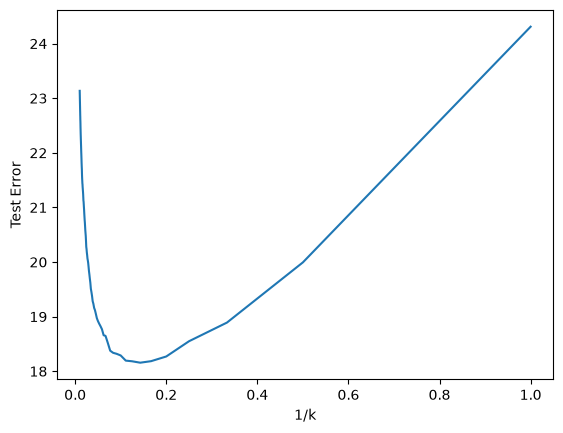

In [ ]:
plt.plot([1/k for k in range(1, 101)], test_errors_scaled)

plt.xlabel("1/k")
plt.ylabel("Test Error")

Text(0, 0.5, 'Train Error')

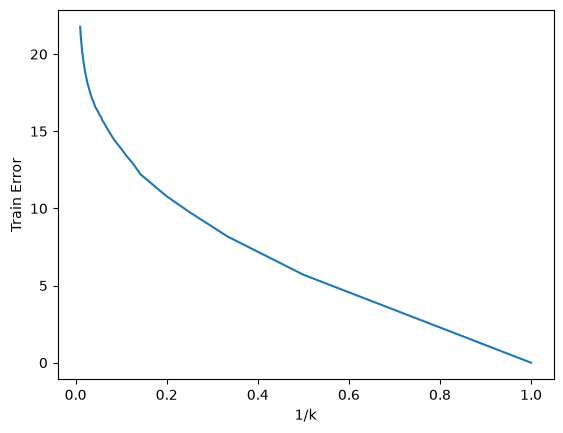

In [ ]:
plt.plot([1/k for k in range(1, 101)], train_errors_scaled)

plt.xlabel("1/k")
plt.ylabel("Train Error")


The normalized KNN regression model performed very similarly to the linear regression models, however, the normalized KNN model did have a slightly lower test MSE than the linear regression model. The improved model from part (h) had a test MSE of approximately **18.69** while the normalized KNN model had a test MSE of approximately **18.16**, making its test error slightly lower. This suggests that KNN was able to capture some of the relationships in the data that were not fully captured by the linear regression model. However, as the difference in test MSE is relatively small, the two approaches performed fairly similarly on the test data.


## j)

# 2.4.1

For each of parts (a) through (d), indicate whether we would generally
expect the performance of a flexible statistical learning method to be
better or worse than an inflexible method. Justify your answer.

(a) The sample size n is extremely large, and the number of predic-
tors p is small.

There is enough data points here that it has the capability to learn and find pattern in the large sample. This would give a flexible method a stronger advantage.

(b) The number of predictors p is extremely large, and the number
of observations n is small.

With a small amount of observations and a large amount of predictors, a flexible model would be prone to overfitting and catering too much to the data that we have. In this case, an inflexible method would be more appropriate.

(c) The relationship between the predictors and response is highly
non-linear.

Inflexible methods assume that the relationship is linear, and, as this data is non-linear, it would not predict as accurately as it would with a flexible model.

(d) The variance of the error terms, i.e. σ2 = Var(ϵ), is extremely
high.

With data that contains a lot of noise, a flexible model might follow it and end up catering to the noise. Inflexible models would ignore the noise and find the average trend instead.

# 2.4.7

The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.
Suppose we wish to use this data set to make a prediction for Y when X1 = X2 = X3 = 0 using K-nearest neighbors.

Obs. X1 X2 X3 Y
1 0 3 0 Red
2 2 0 0 Red
3 0 1 3 Red
4 0 1 2 Green
5 -1 0 1 Green
6 1 1 1 Red

(a) Compute the Euclidean distance between each observation and
the test point, X1 = X2 = X3 = 0.

Obs 1: sqrt(0^2 + 3^2 + 0^2) = 3

Obs 2: sqrt(2^2 + 0^2 + 0^2) = 2

Obs 3: sqrt(0^2 + 1^2 + 3^2) = sqrt(10) = 3.162

Obs 4: sqrt(0^2 + 1^2 + 2^2) = sqrt(5) = 2.236

Obs 5: sqrt((-1)^2 + 0^2 + 1^2)= sqrt(2) = 1.414

Obs 6: sqrt(1^2 + 1^2 + 1^2)= sqrt(3) = 1.732

(b) What is our prediction with K = 1? Why?

When predicting for a point (0, 0, 0) when K = 1, we look for the one point that has the closest distance to our point. This is obs 5, with a distance of 1.414 and is Green. So our prediction for point (0, 0, 0) is Green.

(c) What is our prediction with K = 3? Why?

When predicting for a point (0, 0, 0) when K = 3, we look for the three points that has the closest distance to our point. This is obs 5, obs 6, and obs 2. This gives us Green, Red, and Red. Because 2/3 are red, it wins and we would predict our point is also red.

(d) If the Bayes decision boundary in this problem is highly non-
linear, then would we expect the best value for K to be large or
small? Why?

When looking at the properties of small and large K values, small k values results in low bias and a more rigid boundary, which, if we are not careful, can cause overfitting. Large values of K results in a smooth, possibly underfitted boundary. If we are looking at which K value would result un a highly non-linear boundary, we would find a small k value would create that.

